#0. Set up/Initialization
We will be using packages such as:


*   Numpy
*   pandas
*   Sklearn
*   Tensorflow
* Matplotlib





In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
%matplotlib inline

from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score # Added f1_score and roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import optimizers

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # 3D plots

import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42) # Set TensorFlow seed for reproducibility

#1. Import Datasets

The data is already split into Train and Test sets. We will have to do some preprocessing such as:


*   Extract target variable "contaminated'
*   Normalize the data using StandardScaler() from sklearn



In [ ]:
train = pd.read_csv('/content/train_set.csv')
test = pd.read_csv('/content/test_set.csv')

print(train.shape)
print(test.shape)


(8067, 26)
(2017, 26)


In [ ]:
# Split into features and target for train set
X_train = train.drop(['contaminated'], axis=1)
y_train = train['contaminated']

In [ ]:
#Normalization of features with StandardScaler
train_scaler = StandardScaler()
train_scaler.fit(X_train)
X_train = pd.DataFrame(train_scaler.transform(X_train), columns=X_train.columns)

In [ ]:
# Split into features and target for test set
X_test = test.drop(['contaminated'], axis=1)
y_test = test['contaminated']

In [ ]:
#Normalization of features with StandardScaler
test_scaler = StandardScaler()
test_scaler.fit(X_test)
X_test = pd.DataFrame(test_scaler.transform(X_test), columns=X_test.columns)

#2. Define NN Model using Tensorflow

(Once we decide on a model, we'll define our layers here)






In [ ]:
model = Sequential([
    Dense(150, input_shape=(25,)),
    Activation('relu'),
    Dense(1),
    Activation('sigmoid')
])

In [ ]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 150)            │         3,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │           151 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,051 (15.82 KB)

 Trainable params: 4,051 (15.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
training=model.fit(X_train,
          y_train,
          epochs=50,
          validation_split=.2,
          batch_size=607,
          verbose=1,
          )

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7085 - loss: 0.6206 - val_accuracy: 0.7354 - val_loss: 0.5664
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7462 - loss: 0.5511 - val_accuracy: 0.7348 - val_loss: 0.5298
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7601 - loss: 0.5193 - val_accuracy: 0.7571 - val_loss: 0.5066
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7669 - loss: 0.5025 - val_accuracy: 0.7664 - val_loss: 0.4924
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7742 - loss: 0.4920 - val_accuracy: 0.7708 - val_loss: 0.4844
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7790 - loss: 0.4852 - val_accuracy: 0.7714 - val_loss: 0.4792
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7830 - loss: 0.4804 - val_accuracy: 0.7763 - val_loss: 0.4756
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7866 - loss: 0.4766 - val_accuracy: 0.7763 - val

#3. Plot the Train and Validation Accuracy & Loss

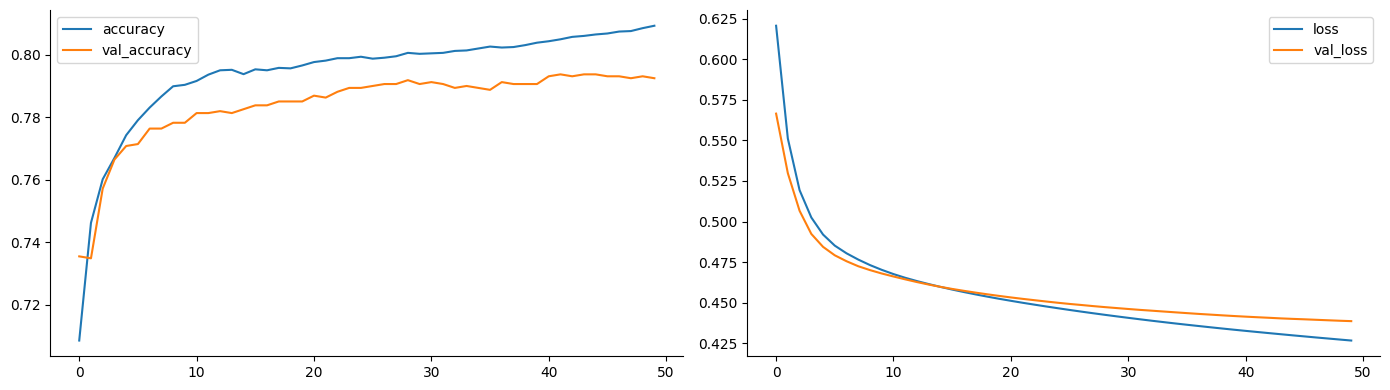

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
pd.DataFrame(training.history)[['accuracy', 'val_accuracy']].plot(ax=axes[0])
pd.DataFrame(training.history)[['loss', 'val_loss']].plot(ax=axes[1])
sns.despine()
fig.tight_layout();

#4. Evaluate Model Performance
We will be using Accuracy, Recall, Precision, AUC, and F1 Score to evaluate our NN model.

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


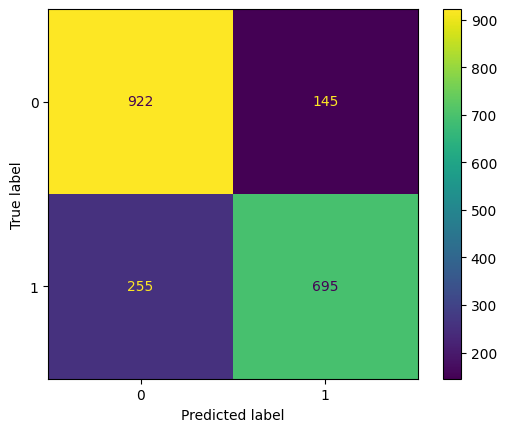

In [ ]:
predicted_proba_orig = model.predict(X_test)

predicted_orig = tf.squeeze(predicted_proba_orig)
predicted_orig = np.array([1 if x >= 0.5 else 0 for x in predicted_orig])
actual = np.array(y_test)
conf_mat = confusion_matrix(actual, predicted_orig)
displ = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
displ.plot()

In [ ]:
#Final Accuracy, Precision, and Recall Scores

accuracy_orig = accuracy_score(actual, predicted_orig)
precision_orig = precision_score(actual, predicted_orig)
recall_orig = recall_score(actual, predicted_orig)
f1_orig = f1_score(actual, predicted_orig)
auc_orig = roc_auc_score(actual, predicted_proba_orig)

print(f'Accuracy: {accuracy_orig}')
print(f'Precision: {precision_orig}')
print(f'Recall: {recall_orig}')
print(f'F1 Score: {f1_orig}')
print(f'AUC Score: {auc_orig}')

Accuracy: 0.8016856717897868
Precision: 0.8273809523809523
Recall: 0.7315789473684211
F1 Score: 0.776536312849162
AUC Score: 0.8863503181571548


#5. Model Optimization
We will explore 5 techniques to improve the model.

## I. Adding a Hidden Layer
We will start by experimenting with an additional hidden layer of 75 nodes.

In [ ]:
model_optimized1 = Sequential([
    Dense(150, input_shape=(25,)),
    Activation('relu'),
    Dense(75, input_shape=(25,)),
    Activation('relu'),
    Dense(1),
    Activation('sigmoid')
])

In [ ]:
model_optimized1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
training=model_optimized1.fit(X_train,
          y_train,
          epochs=50,
          validation_split=.2,
          batch_size=607,
          verbose=1,
          )

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6633 - loss: 0.6427 - val_accuracy: 0.7423 - val_loss: 0.5718
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7621 - loss: 0.5378 - val_accuracy: 0.7652 - val_loss: 0.5065
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7739 - loss: 0.4965 - val_accuracy: 0.7689 - val_loss: 0.4812
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7830 - loss: 0.4807 - val_accuracy: 0.7751 - val_loss: 0.4732
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7903 - loss: 0.4707 - val_accuracy: 0.7819 - val_loss: 0.4672
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7923 - loss: 0.4641 - val_accuracy: 0.7819 - val_loss: 0.4633
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7928 - loss: 0.4591 - val_accuracy: 0.7813 - val_loss: 0.4596
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7944 - loss: 0.4550 - val_accuracy: 0.7838 - v

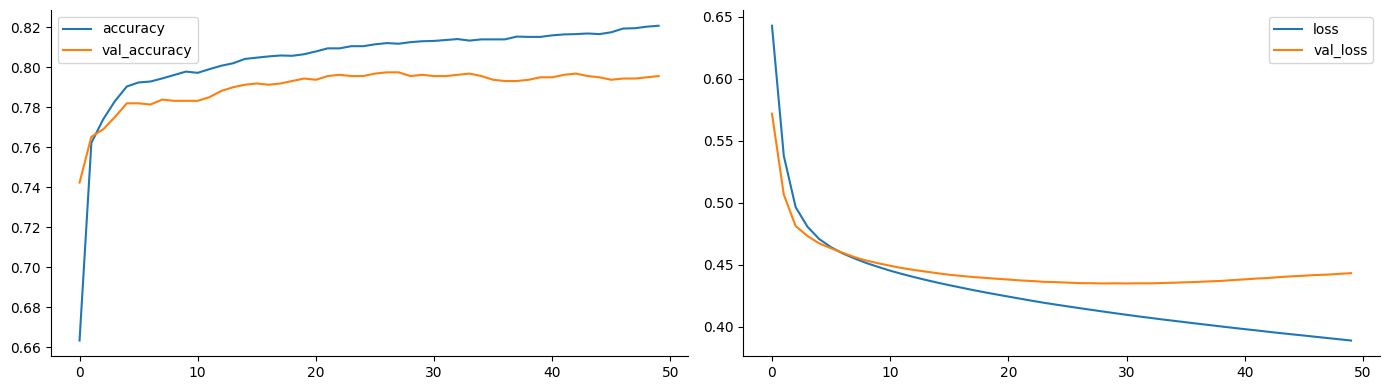

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
pd.DataFrame(training.history)[['accuracy', 'val_accuracy']].plot(ax=axes[0])
pd.DataFrame(training.history)[['loss', 'val_loss']].plot(ax=axes[1])
sns.despine()
fig.tight_layout();

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


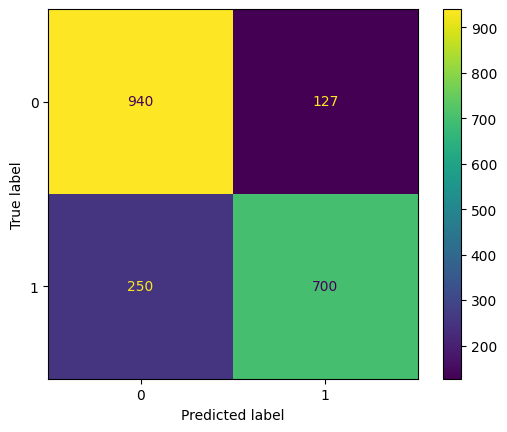

In [ ]:
predicted_proba_opt1 = model_optimized1.predict(X_test)

predicted = tf.squeeze(predicted_proba_opt1)
predicted = np.array([1 if x >= 0.5 else 0 for x in predicted])
actual = np.array(y_test)
conf_mat = confusion_matrix(actual, predicted)
displ = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
displ.plot()

In [ ]:
optimized_accuracy = accuracy_score(actual, predicted)
optimized_precision = precision_score(actual, predicted)
optimized_recall = recall_score(actual, predicted)
optimized_f1 = f1_score(actual, predicted)
optimized_auc = roc_auc_score(actual, predicted_proba_opt1)

print(f'Original Model Accuracy: {accuracy_orig}')
print(f'Original Model Precision: {precision_orig}')
print(f'Original Model Recall: {recall_orig}')
print(f'Original Model F1 Score: {f1_orig}')
print(f'Original Model AUC Score: {auc_orig}')
print('\n')
print(f'Optimized Model (with additional layer) Accuracy: {optimized_accuracy}')
print(f'Optimized Model (with additional layer) Precision: {optimized_precision}')
print(f'Optimized Model (with additional layer) Recall: {optimized_recall}')
print(f'Optimized Model (with additional layer) F1 Score: {optimized_f1}')
print(f'Optimized Model (with additional layer) AUC Score: {optimized_auc}')

Original Model Accuracy: 0.8016856717897868
Original Model Precision: 0.8273809523809523
Original Model Recall: 0.7315789473684211
Original Model F1 Score: 0.776536312849162
Original Model AUC Score: 0.8863503181571548


Optimized Model (with additional layer) Accuracy: 0.8130887456618741
Optimized Model (with additional layer) Precision: 0.8464328899637243
Optimized Model (with additional layer) Recall: 0.7368421052631579
Optimized Model (with additional layer) F1 Score: 0.7878446820483962
Optimized Model (with additional layer) AUC Score: 0.8931460563310808


We can see slight improvements in metrics with the deeper neural network.

Let's look at Early Stopping to see if further improvements can be made.

## II. Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Re-initialize the optimized model structure
model_optimized_es = Sequential([
    Dense(150, input_shape=(25,)),
    Activation('relu'),
    Dense(75),
    Activation('relu'),
    Dense(1),
    Activation('sigmoid')
])

# Compile the model
model_optimized_es.compile(optimizer='adam',
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

# Train the model with early stopping
training_es = model_optimized_es.fit(X_train,
                                    y_train,
                                    epochs=100, # Set a higher number of epochs
                                    validation_split=.2,
                                    batch_size=607,
                                    verbose=1,
                                    callbacks=[early_stopping])

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6825 - loss: 0.6359 - val_accuracy: 0.7299 - val_loss: 0.5576
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7612 - loss: 0.5291 - val_accuracy: 0.7627 - val_loss: 0.5009
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7742 - loss: 0.4952 - val_accuracy: 0.7664 - val_loss: 0.4793
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7857 - loss: 0.4810 - val_accuracy: 0.7763 - val_loss: 0.4718
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7902 - loss: 0.4733 - val_accuracy: 0.7776 - val_loss: 0.4663
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7940 - loss: 0.4678 - val_accuracy: 0.7776 - val_loss: 0.4620
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7945 - loss: 0.4632 - val_accuracy: 0.7782 - val_loss: 0.4589
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7942 - loss: 0.4588 - val_accuracy: 0.

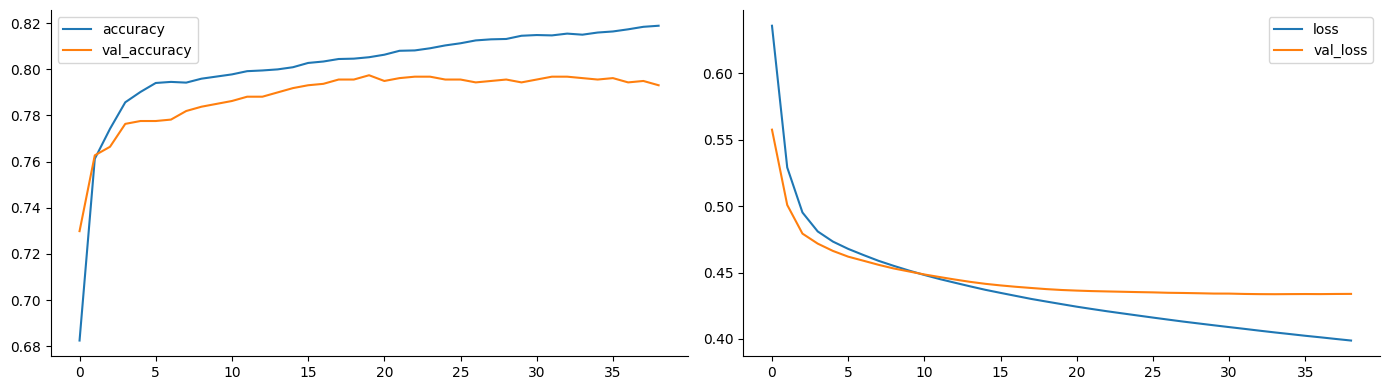

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
pd.DataFrame(training_es.history)[['accuracy', 'val_accuracy']].plot(ax=axes[0])
pd.DataFrame(training_es.history)[['loss', 'val_loss']].plot(ax=axes[1])
sns.despine()
fig.tight_layout();

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


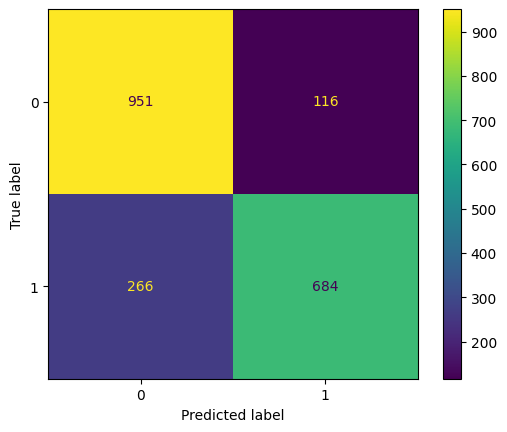

In [ ]:
predicted_proba_es = model_optimized_es.predict(X_test)

predicted_es_cm = tf.squeeze(predicted_proba_es)
predicted_es_cm = np.array([1 if x >= 0.5 else 0 for x in predicted_es_cm])
actual_es_cm = np.array(y_test)
conf_mat_es = confusion_matrix(actual_es_cm, predicted_es_cm)
displ_es = ConfusionMatrixDisplay(confusion_matrix=conf_mat_es)
displ_es.plot()

In [ ]:
es_accuracy = accuracy_score(actual_es_cm, predicted_es_cm)
es_precision = precision_score(actual_es_cm, predicted_es_cm)
es_recall = recall_score(actual_es_cm, predicted_es_cm)
es_f1 = f1_score(actual_es_cm, predicted_es_cm)
es_auc = roc_auc_score(actual_es_cm, predicted_proba_es)

print(f'Original Model Accuracy: {accuracy_orig}')
print(f'Original Model Precision: {precision_orig}')
print(f'Original Model Recall: {recall_orig}')
print(f'Original Model F1 Score: {f1_orig}')
print(f'Original Model AUC Score: {auc_orig}')
print('\n')
print(f'Optimized Model (with additional layer) Accuracy: {optimized_accuracy}')
print(f'Optimized Model (with additional layer) Precision: {optimized_precision}')
print(f'Optimized Model (with additional layer) Recall: {optimized_recall}')
print(f'Optimized Model (with additional layer) F1 Score: {optimized_f1}')
print(f'Optimized Model (with additional layer) AUC Score: {optimized_auc}')
print('\n')
print(f'Optimized Model (with Early Stopping) Accuracy: {es_accuracy}')
print(f'Optimized Model (with Early Stopping) Precision: {es_precision}')
print(f'Optimized Model (with Early Stopping) Recall: {es_recall}')
print(f'Optimized Model (with Early Stopping) F1 Score: {es_f1}')
print(f'Optimized Model (with Early Stopping) AUC Score: {es_auc}')

Original Model Accuracy: 0.8016856717897868
Original Model Precision: 0.8273809523809523
Original Model Recall: 0.7315789473684211
Original Model F1 Score: 0.776536312849162
Original Model AUC Score: 0.8863503181571548


Optimized Model (with additional layer) Accuracy: 0.8130887456618741
Optimized Model (with additional layer) Precision: 0.8464328899637243
Optimized Model (with additional layer) Recall: 0.7368421052631579
Optimized Model (with additional layer) F1 Score: 0.7878446820483962
Optimized Model (with additional layer) AUC Score: 0.8931460563310808


Optimized Model (with Early Stopping) Accuracy: 0.8106098165592464
Optimized Model (with Early Stopping) Precision: 0.855
Optimized Model (with Early Stopping) Recall: 0.72
Optimized Model (with Early Stopping) F1 Score: 0.7817142857142857
Optimized Model (with Early Stopping) AUC Score: 0.891021062496917


We can see the Optimized Model with Early Stopping does not demonstrate significant improvements. Next, we will try Dropout.

## III. Dropout

In [ ]:
from tensorflow.keras.layers import Dropout

model_optimized_dropout = Sequential([
    Dense(150, input_shape=(25,)),
    Activation('relu'),
    Dropout(0.3), # Added Dropout layer with a rate of 0.3
    Dense(75),
    Activation('relu'),
    Dense(1),
    Activation('sigmoid')
])

model_optimized_dropout.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 150)            │         3,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_65 (Activation)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_66 (Activation)      │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            76 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,301 (59.77 KB)

 Trainable params: 15,301 (59.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_optimized_dropout.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
training_dropout = model_optimized_dropout.fit(X_train,
          y_train,
          epochs=50,
          validation_split=.2,
          batch_size=607,
          verbose=1)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6664 - loss: 0.6425 - val_accuracy: 0.7454 - val_loss: 0.5609
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7565 - loss: 0.5464 - val_accuracy: 0.7646 - val_loss: 0.5070
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7640 - loss: 0.5128 - val_accuracy: 0.7689 - val_loss: 0.4834
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7761 - loss: 0.4910 - val_accuracy: 0.7782 - val_loss: 0.4734
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7776 - loss: 0.4875 - val_accuracy: 0.7813 - val_loss: 0.4662
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7832 - loss: 0.4786 - val_accuracy: 0.7800 - val_loss: 0.4630
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7818 - loss: 0.4761 - val_accuracy: 0.7770 - val_loss: 0.4599
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7834 - loss: 0.4733 - val_accuracy: 0.7757 - v

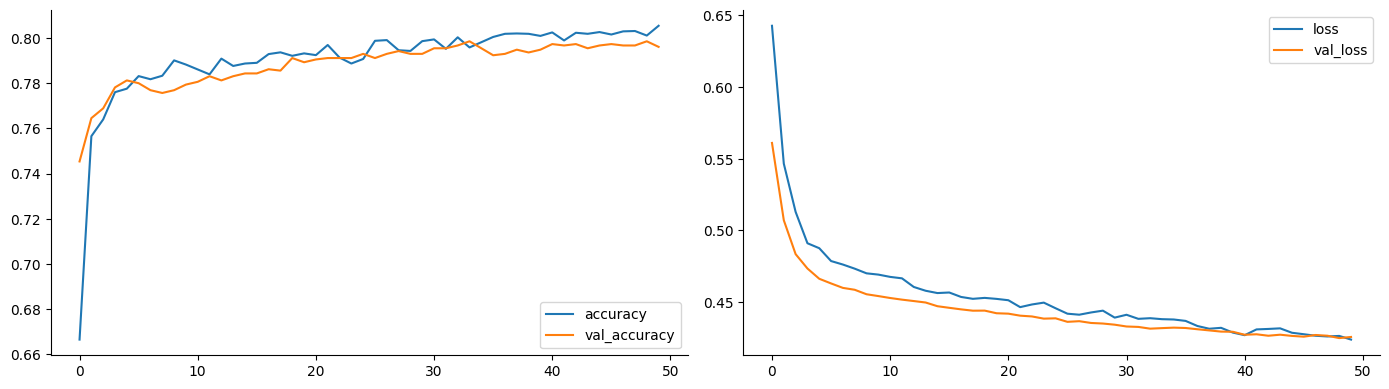

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
pd.DataFrame(training_dropout.history)[['accuracy', 'val_accuracy']].plot(ax=axes[0])
pd.DataFrame(training_dropout.history)[['loss', 'val_loss']].plot(ax=axes[1])
sns.despine()
fig.tight_layout();

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


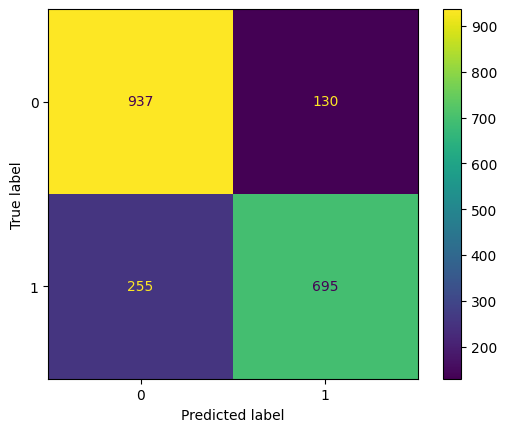

In [ ]:
predicted_proba_dropout = model_optimized_dropout.predict(X_test)

predicted_dropout_cm = tf.squeeze(predicted_proba_dropout)
predicted_dropout_cm = np.array([1 if x >= 0.5 else 0 for x in predicted_dropout_cm])
actual_dropout_cm = np.array(y_test)
conf_mat_dropout = confusion_matrix(actual_dropout_cm, predicted_dropout_cm)
displ_dropout = ConfusionMatrixDisplay(confusion_matrix=conf_mat_dropout)
displ_dropout.plot()

In [ ]:
do_accuracy = accuracy_score(actual_dropout_cm, predicted_dropout_cm)
do_precision = precision_score(actual_dropout_cm, predicted_dropout_cm)
do_recall = recall_score(actual_dropout_cm, predicted_dropout_cm)
do_f1 = f1_score(actual_dropout_cm, predicted_dropout_cm)
do_auc = roc_auc_score(actual_dropout_cm, predicted_proba_dropout)

print(f'Original Model Accuracy: {accuracy_orig}')
print(f'Original Model Precision: {precision_orig}')
print(f'Original Model Recall: {recall_orig}')
print(f'Original Model F1 Score: {f1_orig}')
print(f'Original Model AUC Score: {auc_orig}')
print('\n')
print(f'Optimized Model (with additional layer) Accuracy: {optimized_accuracy}')
print(f'Optimized Model (with additional layer) Precision: {optimized_precision}')
print(f'Optimized Model (with additional layer) Recall: {optimized_recall}')
print(f'Optimized Model (with additional layer) F1 Score: {optimized_f1}')
print(f'Optimized Model (with additional layer) AUC Score: {optimized_auc}')
print('\n')
print(f'Optimized Model (with Early Stopping) Accuracy: {es_accuracy}')
print(f'Optimized Model (with Early Stopping) Precision: {es_precision}')
print(f'Optimized Model (with Early Stopping) Recall: {es_recall}')
print(f'Optimized Model (with Early Stopping) F1 Score: {es_f1}')
print(f'Optimized Model (with Early Stopping) AUC Score: {es_auc}')
print('\n')
print(f'Optimized Model (with Dropout) Accuracy: {do_accuracy}')
print(f'Optimized Model (with Dropout) Precision: {do_precision}')
print(f'Optimized Model (with Dropout) Recall: {do_recall}')
print(f'Optimized Model (with Dropout) F1 Score: {do_f1}')
print(f'Optimized Model (with Dropout) AUC Score: {do_auc}')

Original Model Accuracy: 0.8016856717897868
Original Model Precision: 0.8273809523809523
Original Model Recall: 0.7315789473684211
Original Model F1 Score: 0.776536312849162
Original Model AUC Score: 0.8863503181571548


Optimized Model (with additional layer) Accuracy: 0.8130887456618741
Optimized Model (with additional layer) Precision: 0.8464328899637243
Optimized Model (with additional layer) Recall: 0.7368421052631579
Optimized Model (with additional layer) F1 Score: 0.7878446820483962
Optimized Model (with additional layer) AUC Score: 0.8931460563310808


Optimized Model (with Early Stopping) Accuracy: 0.8106098165592464
Optimized Model (with Early Stopping) Precision: 0.855
Optimized Model (with Early Stopping) Recall: 0.72
Optimized Model (with Early Stopping) F1 Score: 0.7817142857142857
Optimized Model (with Early Stopping) AUC Score: 0.891021062496917


Optimized Model (with Dropout) Accuracy: 0.8091224590976698
Optimized Model (with Dropout) Precision: 0.8424242424242424
Op

The Dropout model shows the highest Accuracy and F1 Score. Next, we will change from relu activation to tanh and see if improvements can be made.

## IV. Experiment with 'tanh' Activation Function

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

model_optimized_tanh = Sequential([
    Dense(150, input_shape=(25,)),
    Activation('tanh'), # Changed activation to tanh
    Dense(75),
    Activation('tanh'), # Changed activation to tanh
    Dense(1),
    Activation('sigmoid') # Output layer remains sigmoid for binary classification
])

model_optimized_tanh.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 150)            │         3,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_68 (Activation)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_69 (Activation)      │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 1)              │            76 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_70 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,301 (59.77 KB)

 Trainable params: 15,301 (59.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_optimized_tanh.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
training_tanh = model_optimized_tanh.fit(X_train,
          y_train,
          epochs=100, # Use a higher number of epochs with early stopping
          validation_split=.2,
          batch_size=607,
          verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6433 - loss: 0.6092 - val_accuracy: 0.7305 - val_loss: 0.5304
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7491 - loss: 0.5219 - val_accuracy: 0.7708 - val_loss: 0.4931
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7703 - loss: 0.4984 - val_accuracy: 0.7782 - val_loss: 0.4849
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7755 - loss: 0.4893 - val_accuracy: 0.7819 - val_loss: 0.4820
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7782 - loss: 0.4856 - val_accuracy: 0.7844 - val_loss: 0.4792
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7821 - loss: 0.4824 - val_accuracy: 0.7838 - val_loss: 0.4760
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7851 - loss: 0.4795 - val_accuracy: 0.7856 - val_loss: 0.4728
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7835 - loss: 0.4771 - val_accuracy: 0.

Let's visualize the training history for the model with 'tanh' activation.

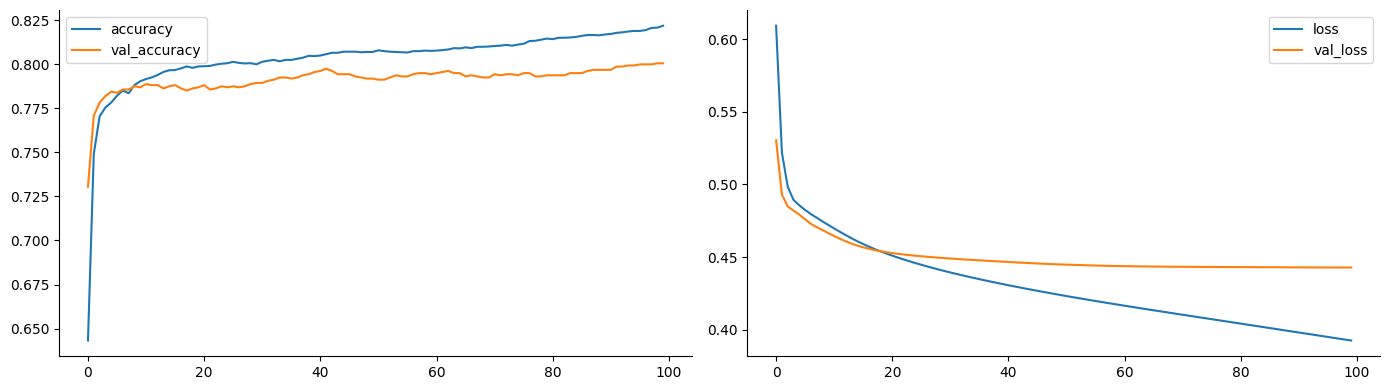

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(ncols=2, figsize=(14,4))
pd.DataFrame(training_tanh.history)[['accuracy', 'val_accuracy']].plot(ax=axes[0])
pd.DataFrame(training_tanh.history)[['loss', 'val_loss']].plot(ax=axes[1])
sns.despine()
fig.tight_layout();

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


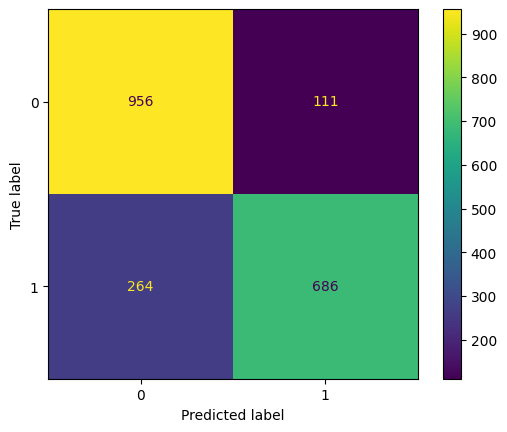

In [ ]:
predicted_proba_tanh = model_optimized_tanh.predict(X_test)

predicted_tanh_cm = tf.squeeze(predicted_proba_tanh)
predicted_tanh_cm = np.array([1 if x >= 0.5 else 0 for x in predicted_tanh_cm])
actual_tanh_cm = np.array(y_test)
conf_mat_tanh = confusion_matrix(actual_tanh_cm, predicted_tanh_cm)
displ_tanh = ConfusionMatrixDisplay(confusion_matrix=conf_mat_tanh)
displ_tanh.plot()

Now, let's evaluate the performance of the model with 'tanh' activation on the test set.

In [ ]:
accuracy_tanh = accuracy_score(actual_tanh_cm, predicted_tanh_cm)
precision_tanh = precision_score(actual_tanh_cm, predicted_tanh_cm)
recall_tanh = recall_score(actual_tanh_cm, predicted_tanh_cm)
f1_tanh = f1_score(actual_tanh_cm, predicted_tanh_cm)
auc_tanh = roc_auc_score(actual_tanh_cm, predicted_proba_tanh)

print(f'Original Model Accuracy: {accuracy_orig}')
print(f'Original Model Precision: {precision_orig}')
print(f'Original Model Recall: {recall_orig}')
print(f'Original Model F1 Score: {f1_orig}')
print(f'Original Model AUC Score: {auc_orig}')
print('\n')
print(f'Optimized Model (with additional layer) Accuracy: {optimized_accuracy}')
print(f'Optimized Model (with additional layer) Precision: {optimized_precision}')
print(f'Optimized Model (with additional layer) Recall: {optimized_recall}')
print(f'Optimized Model (with additional layer) F1 Score: {optimized_f1}')
print(f'Optimized Model (with additional layer) AUC Score: {optimized_auc}')
print('\n')
print(f'Optimized Model (with Early Stopping) Accuracy: {es_accuracy}')
print(f'Optimized Model (with Early Stopping) Precision: {es_precision}')
print(f'Optimized Model (with Early Stopping) Recall: {es_recall}')
print(f'Optimized Model (with Early Stopping) F1 Score: {es_f1}')
print(f'Optimized Model (with Early Stopping) AUC Score: {es_auc}')
print('\n')
print(f'Optimized Model (with Dropout) Accuracy: {do_accuracy}')
print(f'Optimized Model (with Dropout) Precision: {do_precision}')
print(f'Optimized Model (with Dropout) Recall: {do_recall}')
print(f'Optimized Model (with Dropout) F1 Score: {do_f1}')
print(f'Optimized Model (with Dropout) AUC Score: {do_auc}')
print('\n')
print(f'Optimized Model (with tanh Activation) Accuracy: {accuracy_tanh}')
print(f'Optimized Model (with tanh Activation) Precision: {precision_tanh}')
print(f'Optimized Model (with tanh Activation) Recall: {recall_tanh}')
print(f'Optimized Model (with tanh Activation) F1 Score: {f1_tanh}')
print(f'Optimized Model (with tanh Activation) AUC Score: {auc_tanh}')
print('\n')

Original Model Accuracy: 0.8016856717897868
Original Model Precision: 0.8273809523809523
Original Model Recall: 0.7315789473684211
Original Model F1 Score: 0.776536312849162
Original Model AUC Score: 0.8863503181571548


Optimized Model (with additional layer) Accuracy: 0.8130887456618741
Optimized Model (with additional layer) Precision: 0.8464328899637243
Optimized Model (with additional layer) Recall: 0.7368421052631579
Optimized Model (with additional layer) F1 Score: 0.7878446820483962
Optimized Model (with additional layer) AUC Score: 0.8931460563310808


Optimized Model (with Early Stopping) Accuracy: 0.8106098165592464
Optimized Model (with Early Stopping) Precision: 0.855
Optimized Model (with Early Stopping) Recall: 0.72
Optimized Model (with Early Stopping) F1 Score: 0.7817142857142857
Optimized Model (with Early Stopping) AUC Score: 0.891021062496917


Optimized Model (with Dropout) Accuracy: 0.8091224590976698
Optimized Model (with Dropout) Precision: 0.8424242424242424
Op

We observe slight dips across all metrics with the tanh Activation. Since the model with the additional layer performs the best, let's try adding one more hidden layer to see if performance improves.

## V. Adding a 3rd Hidden Layer

In [ ]:
model_optimized2 = Sequential([
    Dense(150, input_shape=(X_train.shape[1],)),
    Activation('relu'),
    Dense(75),
    Activation('relu'),
    Dense(30), # Added a third hidden layer with 30 nodes
    Activation('relu'),
    Dense(1),
    Activation('sigmoid')
])

In [ ]:
model_optimized2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
training=model_optimized2.fit(X_train,
          y_train,
          epochs=50,
          validation_split=.2,
          batch_size=607,
          verbose=1)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6792 - loss: 0.6290 - val_accuracy: 0.7646 - val_loss: 0.5664
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7708 - loss: 0.5279 - val_accuracy: 0.7639 - val_loss: 0.4949
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7779 - loss: 0.4888 - val_accuracy: 0.7683 - val_loss: 0.4814
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7871 - loss: 0.4770 - val_accuracy: 0.7708 - val_loss: 0.4732
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7911 - loss: 0.4662 - val_accuracy: 0.7720 - val_loss: 0.4666
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7937 - loss: 0.4588 - val_accuracy: 0.7732 - val_loss: 0.4614
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7950 - loss: 0.4533 - val_accuracy: 0.7782 - val_loss: 0.4579
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7973 - loss: 0.4489 - val_accuracy: 0.7800 - v

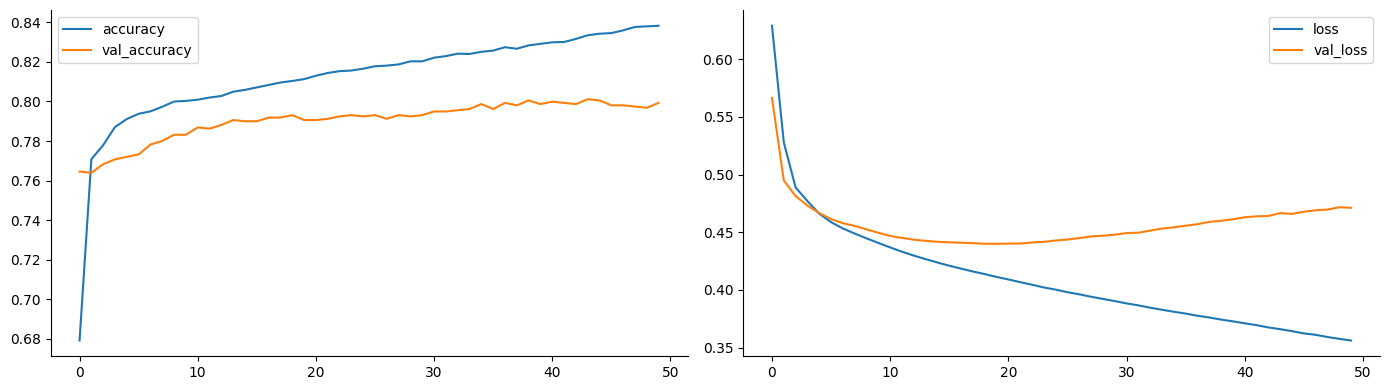

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
pd.DataFrame(training.history)[['accuracy', 'val_accuracy']].plot(ax=axes[0])
pd.DataFrame(training.history)[['loss', 'val_loss']].plot(ax=axes[1])
sns.despine()
fig.tight_layout();

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


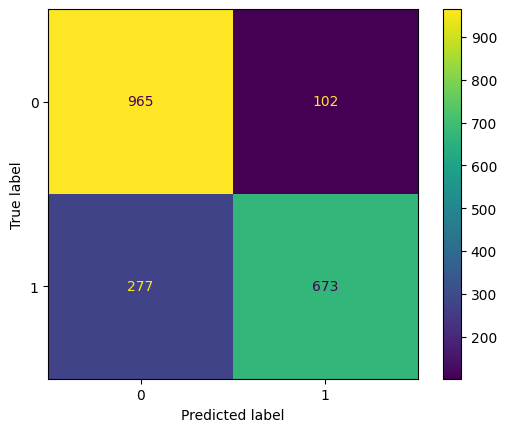

In [ ]:
predicted_proba_opt2 = model_optimized2.predict(X_test)

predicted_opt2 = tf.squeeze(predicted_proba_opt2)
predicted_opt2 = np.array([1 if x >= 0.5 else 0 for x in predicted_opt2])
actual_2 = np.array(y_test)
conf_mat_2 = confusion_matrix(actual_2, predicted_opt2)
displ_2 = ConfusionMatrixDisplay(confusion_matrix=conf_mat_2)
displ_2.plot()

In [ ]:
optimized2_accuracy = accuracy_score(actual_2, predicted_opt2)
optimized2_precision = precision_score(actual_2, predicted_opt2)
optimized2_recall = recall_score(actual_2, predicted_opt2)
optimized2_f1 = f1_score(actual_2, predicted_opt2)
optimized2_auc = roc_auc_score(actual_2, predicted_proba_opt2)

print(f'Original Model Accuracy: {accuracy_orig}')
print(f'Original Model Precision: {precision_orig}')
print(f'Original Model Recall: {recall_orig}')
print(f'Original Model F1 Score: {f1_orig}')
print(f'Original Model AUC Score: {auc_orig}')
print('\n')
print(f'Optimized Model (with additional layer) Accuracy: {optimized_accuracy}')
print(f'Optimized Model (with additional layer) Precision: {optimized_precision}')
print(f'Optimized Model (with additional layer) Recall: {optimized_recall}')
print(f'Optimized Model (with additional layer) F1 Score: {optimized_f1}')
print(f'Optimized Model (with additional layer) AUC Score: {optimized_auc}')
print('\n')
print(f'Optimized Model (with Early Stopping) Accuracy: {es_accuracy}')
print(f'Optimized Model (with Early Stopping) Precision: {es_precision}')
print(f'Optimized Model (with Early Stopping) Recall: {es_recall}')
print(f'Optimized Model (with Early Stopping) F1 Score: {es_f1}')
print(f'Optimized Model (with Early Stopping) AUC Score: {es_auc}')
print('\n')
print(f'Optimized Model (with Dropout) Accuracy: {do_accuracy}')
print(f'Optimized Model (with Dropout) Precision: {do_precision}')
print(f'Optimized Model (with Dropout) Recall: {do_recall}')
print(f'Optimized Model (with Dropout) F1 Score: {do_f1}')
print(f'Optimized Model (with Dropout) AUC Score: {do_auc}')
print('\n')
print(f'Optimized Model (with tanh Activation) Accuracy: {accuracy_tanh}')
print(f'Optimized Model (with tanh Activation) Precision: {precision_tanh}')
print(f'Optimized Model (with tanh Activation) Recall: {recall_tanh}')
print(f'Optimized Model (with tanh Activation) F1 Score: {f1_tanh}')
print(f'Optimized Model (with tanh Activation) AUC Score: {auc_tanh}')
print('\n')
print(f'Optimized Model (with 2 additional layers) Accuracy: {optimized2_accuracy}')
print(f'Optimized Model (with 2 additional layers) Precision: {optimized2_precision}')
print(f'Optimized Model (with 2 additional layers) Recall: {optimized2_recall}')
print(f'Optimized Model (with 2 additional layers) F1 Score: {optimized2_f1}')
print(f'Optimized Model (with 2 additional layers) AUC Score: {optimized2_auc}')

Original Model Accuracy: 0.8016856717897868
Original Model Precision: 0.8273809523809523
Original Model Recall: 0.7315789473684211
Original Model F1 Score: 0.776536312849162
Original Model AUC Score: 0.8863503181571548


Optimized Model (with additional layer) Accuracy: 0.8130887456618741
Optimized Model (with additional layer) Precision: 0.8464328899637243
Optimized Model (with additional layer) Recall: 0.7368421052631579
Optimized Model (with additional layer) F1 Score: 0.7878446820483962
Optimized Model (with additional layer) AUC Score: 0.8931460563310808


Optimized Model (with Early Stopping) Accuracy: 0.8106098165592464
Optimized Model (with Early Stopping) Precision: 0.855
Optimized Model (with Early Stopping) Recall: 0.72
Optimized Model (with Early Stopping) F1 Score: 0.7817142857142857
Optimized Model (with Early Stopping) AUC Score: 0.891021062496917


Optimized Model (with Dropout) Accuracy: 0.8091224590976698
Optimized Model (with Dropout) Precision: 0.8424242424242424
Op

All model configurations perform consistently well. Overall, the additional hidden layer model (1 added layer) offers a strong balance across all metrics, particularly in terms of F1 score.